# Standard Incomplete Markets Model

This notebook introduces and solves the standard incomplete markets model in Julia based on material from Matt Rognlie.

## 1. Model

$$ V(s, a) = \max_{a'} \left\{ u((1+r)a +y(s) - a') + \beta E [V(s', a') |s ] \right\} $$

subject to:
$$ a' \geq \underline{a} $$

Compared to the standard neoclassical growth model, this is simpler in that the interest rate is now exogenous. However, we have to deal with an ocassionally binding constraint which means there is an additional degree of complexity.

### Remark on ocasionally binding constraints

Tricky to deal with - it introduces a kink at $\underline{a}$ into the policy functions. Moreover, with discrete states this propagates into additional kinks elsewhere in the policy function - for example, kink at the level of assets where I am going to exactly hit $\underline{a}$ in four periods if this state $s$ persists. 

This means that one using smooth interpolation methods like Chebyshev or splines are unlikely to work well. Therefore, we will work with the old mainstay - grids and linear interpolation

### Optimality Conditions
We have the standard FOC and envelope conditions

\begin{align*}
u'(c) &\geq \beta E \left[V_a(s',a') |s  \right] \\
V_a(s, a) &= (1+r)u'(c)
\end{align*}

with equality if the constraint does not bind.  Combining we get the standard Euler Equation

$$ u'(c_t) \geq \beta  (1+r) E [u'(c_{t+1} ) |s ] $$

Now lets write this in terms of policy functions and assume that the constraint does not bind. Given function for tomorrow's consumption $c_+$ let $c^{endog}$ be a function for consumption today that satisfies the Euler equation but is specified in terms of tomorrow's assets $a_+$

$$ c^{endog}(s,a_+) = (u')^{-1} \left( \beta  (1+r) E [u'(c_+(s_+, a_+ ) | s ] \right) $$

Once we have $c^{endog}$ we have the solve the following system of equations

\begin{align*}
(1+r)a + y(s) &= a_+ + c^{endog}(s,a_+) \\
c(s, a(s,a_+)) &= c^{endog}(s,a_+)
\end{align*}

where $a(s,a_+)$ denotes the inverse of the policy rule - i.e the level of assets today such that you choose $a_+$ when your state today is $s$. Then we use the endogenous grid points dark magic - where we interpolate the points

$$ (c^{endog}(s,a_+) + a_+, \ c^{endog}(s, a_+)) $$

at $(1+r)a + y(s)$ and thus we get $c(s, a)$ at those points.

Finally, how do we deal with the constraint? For all $a_+ < \underline{a}$ we know that the constraint binds, so we can just set $a_+ = \underline{a}$ at all such points.

## 2. Implementation

First define a class with parameters for the model using the `Parameters` library

In [32]:
using Parameters

@with_kw struct Params
    β::Float64 = 0.95
    r::Float64 = 0.03 
    ρ::Float64 = 0.975
    σ::Float64 = 0.7
end

Params

Now a function to get the discretized states for income using the module `markov_approx.jl` 

In [33]:
include("../src/markov_approx.jl")

function ProductivityProcess(p::Params)
    @unpack ρ, σ  = p
    y, p, Π = markov_tauchen(ρ, σ, N=7, m=2)
end


ProductivityProcess (generic function with 1 method)

Now we define the important function - the routine that implements the backward iteration using the endogenous grid point method and the function to compute the steady state

In [34]:
using LinearAlgebra, Interpolations

function backward_iterate(c₊, a, y, Π, up, up_inv, p::Params)
    
    coh = (1+p.r)*a .+ y'
    c_endog = up_inv( p.β * (1+p.r) * up(c₊) * Π')
    c = similar(c_endog)
    for (s, yi) in enumerate(y)
        G = LinearInterpolation(c_endog[:, s] + a, c_endog[:, s],  extrapolation_bc = Line() )
        c[:, s] = G.(coh[:,s])
    end
    
    # deals with the constraint - could be improved
    a₊ = coh - c 
    a₊[a₊ .< a[1]] .= a[1]
    c = coh - a₊
    
    return c, a₊
end


backward_iterate (generic function with 1 method)

In [35]:
function ss_policy(a, y, Π, up, up_inv, p::Params; maxit = 10000, tol = 1E-9)
    
    coh = (1+p.r)*a .+ y'
    # initial guess for policy function
    c = 0.2 * coh
    
    for it in 1:maxit
        c_new, a_new = backward_iterate(c, a, y, Π, up, up_inv, p)
        if mod(it, 10) ≈ 0 && norm(c_new - c) < tol
            #println("Convergence in $it iterations!")
            return c_new, a_new
        end
        c = c_new
    end
end


ss_policy (generic function with 1 method)

Finally a function to construct a log-spaced grid since we want a grid that is very dense close to the constraint, were things are very nonlinear.

In [36]:
function geomspace(amin::Float64, amax::Float64, N::Int64; pivot = 0.1)
    grid = 10 .^ (range(log10(amin+pivot), log10(amax+pivot),length=N)) .- pivot
    grid[1], grid[end] = amin, amax
    return grid
end

geomspace (generic function with 1 method)

Now the calibration we will use

In [37]:
function solveIncompleteMarkets(amin, amax, N, p::Params)
    @assert p.β * (1 + p.r) ≤ 1 # need this for problem to be well defined
    
    y, pr, Π = ProductivityProcess(p)
    up(c) = 1 ./ c
    up_inv(c) = 1 ./ c
    
    a = geomspace(amin, amax, N)
    c, a₊ = ss_policy(a, y, Π, up, up_inv, p)
    
    return c, a₊, a
end

solveIncompleteMarkets (generic function with 1 method)

In [38]:
c, a₊, a = solveIncompleteMarkets(0., 200., 500, Params());
y, pr, Π = ProductivityProcess(Params());

It works, now lets see how we are doing in terms of time:

In [39]:
using BenchmarkTools
@btime solveIncompleteMarkets(0., 200., 500, Params());

  68.748 ms (20782 allocations: 95.16 MiB)


Pretty good, we are close to Matt's time in Python could probably do better by vectorizing the interpolation step. 

Let's see how the policy functions look:

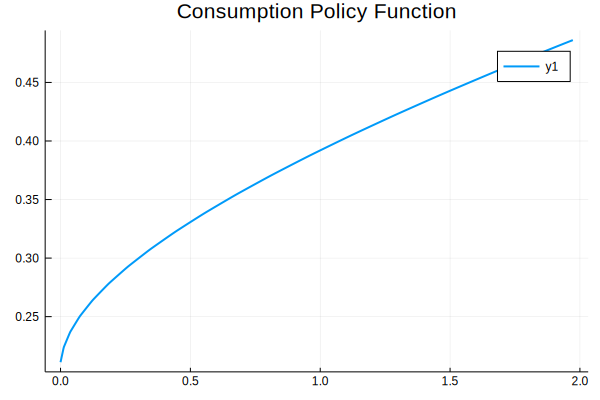

In [40]:
using Plots
plot(a[1:200], c[1:200,1], lw = 2, title = "Consumption Policy Function")

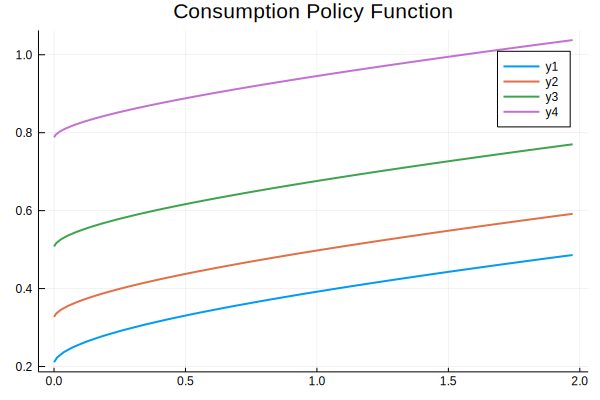

In [41]:
plot(a[1:200], c[1:200,1:4], lw = 2, title = "Consumption Policy Function")

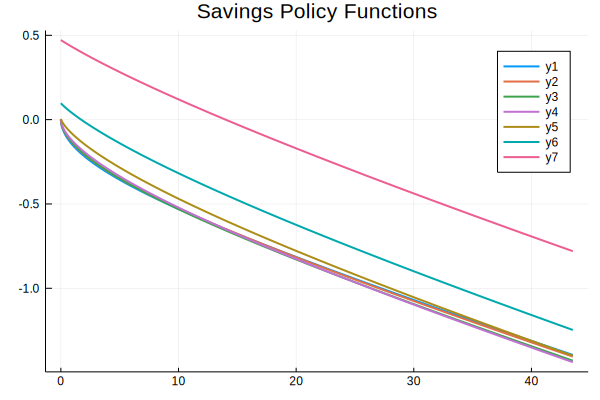

In [42]:
plot(a[1:400], a₊[1:400,:] .- a[1:400], lw = 2, title = "Savings Policy Functions")

## Solving for the distribution

We will use the module `distribution.jl` which contains basic functions to discretize policy rule and compute the ergodic distribution of the model via forward iteration

In [47]:
include("../src/distribution.jl")

ergodic_dist (generic function with 1 method)

Compute indices and weights of discretized policy rule:

In [48]:
a₊i = Array{Int64}(undef, length(a), length(y))
pi_a = Array{Float64}(undef, length(a), length(y))
for i in 1:length(y)
    a₊i[:, i], pi_a[:, i] = interpolate_policy(a, a₊[:, i]) 
end

Now solve for the steady state distribution via forward iteration

In [49]:
D = ergodic_dist(Π, a₊i, pi_a; maxit = 10000, tol = 1E-10);

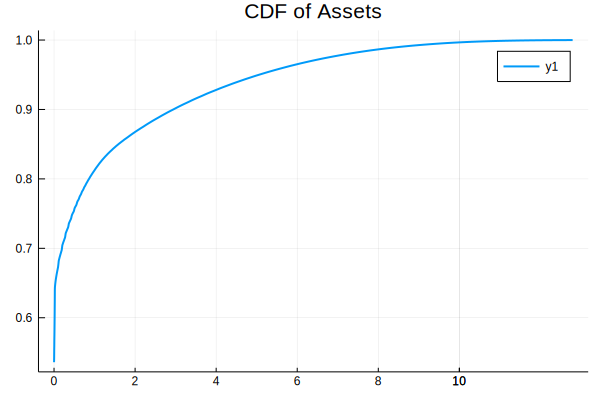

In [50]:
plot(a[1:320], cumsum(sum(D, dims = 2)[1:320], dims = 1), lw = 2, 
title = "CDF of Assets")

## 3. Steady State General Equilibrium

Up until now we have just considered the partial equilibrium version of the model - the household sector in isolation. We now consider a very simple general equilibrium version of the model:
- Labor earnings correspond to endowments of the final good
- Interest is paid on government bonds.
- Government pays for interest with taxes - it maintains bonds constant and levies simple proportional tax against the unit mass of labor:
$$ \tau = r B $$
We will load the module `incomplete_marketsGE.jl` that already has a function that solves for steady state policies and distribution:

In [2]:
include("../src/incomplete_marketsGE.jl");
using QuantEcon

In [55]:
p = Params()
y, pr, Π = markov_rouwenhorst(p.ρ, p.σ, N=7)
up(c) = 1 ./ c
up_inv(c) = 1 ./ c
a = geomspace(0., 200., 500);

In [26]:
function ss_ge(a, y, Π, up, up_inv, B, p::Params)

    function assetMC(r)
        ss(a, (1-r*B)*y, r, Π, up, up_inv, p, verbose = false)[5] - B
    end
    r = brent(assetMC, 0., 1/p.β - 1 - 0.002)
    c, a₊, D, C, A = ss(a, (1-r*B)*y, r, Π, up, up_inv, p::Params; verbose = false)
    return r, c, a₊, D, C, A 
end    

ss_ge (generic function with 1 method)

In [46]:
r = ss_ge(a, y, Π, up, up_inv, 3, Params())[1];
r

0.0065889551001832025

Let's look at what happens when we increase the quantity of bonds issued by the government from 3 to 10:

In [48]:
r = ss_ge(a, y, Π, up, up_inv, 10, Params())[1];
r

0.014192203796616468

## Calibrating steady-state GE

When we calibrate GE parameters we take unknowns as given - in this case the interest rate - and try to find exogenous parameters that yield the postulated interest rate. 

In the example below instead of taking time preference $\beta$ as given and solving for $r$, we will take the equilibrium $r$ as given - since perhaps we can observe it from the data - and solve for the $\beta$ that implies such an equilibrium interest rate. 

In [41]:
function ss_ge_calibrate(a, y, Π, up, up_inv, B, r)
    
    function assetMC(β)
        ss(a, (1-r*B)*y, r, Π, up, up_inv, Params(β = β), verbose = false)[5] - B
    end
    β = brent(assetMC, 0.8, 1/(1+r)-0.004)
    c, a₊, D, C, A = ss(a, (1-r*B)*y, r, Π, up, up_inv, p::Params; verbose = false)
    return β, c, a₊, D, C, A 
end    

ss_ge_calibrate (generic function with 1 method)

In [44]:
β = ss_ge_calibrate(a, y, Π, up, up_inv, 10, r)[1];

In [45]:
β

0.9800000000000506

Let's experiment with changing the parameter of risk aversion of the utility function, in particular let's set $\gamma = 2$

In [52]:
γ = 2
β = ss_ge_calibrate(a, y, Π, (c) -> c.^-γ, (c) -> c.^(-1/γ), 10, r)[1]

0.9707214821329906

Here we get more impatient households - households are more risk averse but since the equilibrium interest rate is fixed, for market clearing to be satisfied it means that we need to assume we are dealing with impatient households. 

Given the extra motive for saving from increased risk aversion, households need to be more impatient if they're going to hold the same amount of bonds at the end of the day.

Finally, let's look at what happens when we change $\rho$ to 0.99 rather than 0.975 - i.e. a more persistent income process:

In [57]:
p = Params(ρ = 0.99)
y_alt, pr_alt, Π_alt = markov_rouwenhorst(p.ρ, p.σ, N=7);
β = ss_ge_calibrate(a, y_alt, Π_alt, up, up_inv, 10, r)[1]

0.9818475163156106

This actually is higher - meaning that there is less motive for saving - we need more patient households when income process is much more persistent. This is not a general result - it depends on the parameterization and is non-monotonic: when income is perfectly persistent we are essentially back in the representative agent case and when it's perfectly transitory its so easy to self insure that we are again back in the representative agent case.

$ \implies$ maximum saving motive - and therefore the lowest calibrated $\beta$ - is somewhere in the middle. To verify this, look at a much lower $\rho$:

In [58]:
p = Params(ρ = 0.8)
y_alt, pr_alt, Π_alt = markov_rouwenhorst(p.ρ, p.σ, N=7);
β = ss_ge_calibrate(a, y_alt, Π_alt, up, up_inv, 10, r)[1]

0.9817647372754071